Importar bibliotecas e carregar os dados

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar o dataset  
df = pd.read_csv('household_power_consumption.csv')

# 2. Criar uma coluna de Datetime e defini-la como index
# O formato da data pode variar ('%d/%m/%Y' ou '%Y-%m-%d'), ajusta se der erro
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Datetime', inplace=True)

# Converter a coluna de consumo para numérico  
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
# The total active power consumed by the household (kilowatts).

# 3. Agregar os dados à hora (média de consumo por hora)
# Isto limpa o ruído e prepara os dados para cruzar com a API Solar
df_hourly = df[['Global_active_power']].resample('H').mean().dropna()

# Vamos usar apenas 1 mês de dados para a prova de conceito ser leve
df_simulacao = df_hourly.copy()

C:\Users\carol\AppData\Local\Temp\ipykernel_4860\3760861039.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
C:\Users\carol\AppData\Local\Temp\ipykernel_4860\3760861039.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df[['Global_active_power']].resample('H').mean().dropna()


3 Perfis de Utilizador

In [ ]:
# Perfil 1: O Consumo Base (Original)
df_simulacao['Perfil_1_Original'] = df_simulacao['Global_active_power']

# Perfil 2: Trabalhador de Escritório (Fora de casa 9h-18h, picos à noite)
def aplicar_perfil_escritorio(row):
    hora = row.name.hour
    consumo_base = row['Perfil_1_Original']
    if 9 <= hora <= 17:
        return consumo_base * 0.4  # Reduz 60% durante o dia
    elif 19 <= hora <= 23:
        return consumo_base * 1.5  # Aumenta 50% à noite
    else:
        return consumo_base

df_simulacao['Perfil_2_Escritorio'] = df_simulacao.apply(aplicar_perfil_escritorio, axis=1)

# Perfil 3: Família Numerosa (Consumo base maior + ruído aleatório para simular imprevistos)
np.random.seed(42)  
ruido = np.random.normal(0, 0.3, len(df_simulacao)) 
df_simulacao['Perfil_3_Familia'] = (df_simulacao['Perfil_1_Original'] * 1.8) + ruido

# Garantir que não há valores de consumo negativos por causa do ruído
df_simulacao['Perfil_3_Familia'] = df_simulacao['Perfil_3_Familia'].clip(lower=0.1)

# Apagar a coluna original para o dataset ficar limpo
df_simulacao.drop(columns=['Global_active_power'], inplace=True)

Visualizar e Exportar

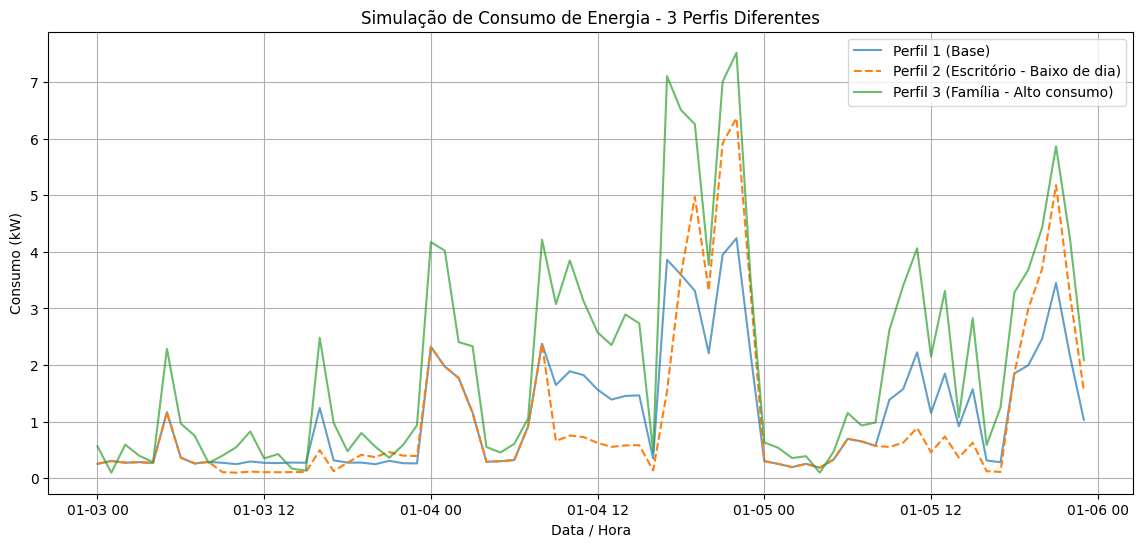

Dataset gerado com sucesso!


In [ ]:
# 1. Visualizar 3 dias típicos para ver a diferença
dias_teste = df_simulacao.loc['2007-01-03':'2007-01-05']

plt.figure(figsize=(14, 6))
plt.plot(dias_teste.index, dias_teste['Perfil_1_Original'], label='Perfil 1 (Base)', alpha=0.7)
plt.plot(dias_teste.index, dias_teste['Perfil_2_Escritorio'], label='Perfil 2 (Escritório - Baixo de dia)', linestyle='--')
plt.plot(dias_teste.index, dias_teste['Perfil_3_Familia'], label='Perfil 3 (Família - Alto consumo)', alpha=0.7)
# Trabalhar à noite, home office,... 

plt.title('Simulação de Consumo de Energia - 3 Perfis Diferentes')
plt.ylabel('Consumo (kW)')
plt.xlabel('Data / Hora')
plt.legend()
plt.grid(True)
plt.show()

# 2. Exportar o resultado final para CSV
df_simulacao.to_csv('dataset_consumo_simulado.csv')
print("Dataset gerado com sucesso!")